In [27]:
# EXPERIMENT_ID = "2026-01-08_07-54-21" # reverse, various parameters
# EXPERIMENT_ID = "2026-01-08_08-41-00"  # forward, various parameters

# EXPERIMENT_ID = "2026-01-13_12-46-04"  # reverse, max_delta=0.05
# EXPERIMENT_ID = "2026-01-13_13-20-27"  # reverse, max_delta=0.01

EXPERIMENT_ID = "2026-01-13_14-02-31"  # reverse, max_delta=0.01, longer z

PATH_TO_RESULTS_FOLDER = f".result/{EXPERIMENT_ID}/"

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as constants
from wave_optics_propagation.analytics import (
    free_space_propagated_gaussian_wavefront,
    gaussian_signal,
    propagated_gaussian_wavefront_hitting_lens,
)
from wave_optics_propagation.visualization import plot_wavefunction

from wave_optics_propagation_enhanced.parameters import ExperimentParameters
from wave_optics_propagation_enhanced.result import ExperimentResult

## Pre-processing


In [29]:
params = ExperimentParameters.from_file(path=PATH_TO_RESULTS_FOLDER)
results = ExperimentResult.from_file(path=PATH_TO_RESULTS_FOLDER)

In [30]:
snapshots = results.snapshots


def process_statevector(statevector: np.ndarray) -> np.ndarray:
    return statevector.flatten()


initial_statevector = process_statevector(snapshots[f"step_{0}"])

lens_statevectors = [
    process_statevector(snapshots[f"step_lens_{i}"])
    if f"step_lens_{i}" in snapshots
    else None
    for i in range(params.lens_slices)
]
after_lens_statevectors = [
    process_statevector(snapshots[f"step_after_lens_{i + 1}"])
    if f"step_after_lens_{i + 1}" in snapshots
    else None
    for i in range(params.num_of_steps_after_lens)
]

In [31]:
# principle_plane_position = params.lens_thickness
# classical_ideal_statevectors

## Wavefunction plots


Plotting initial state


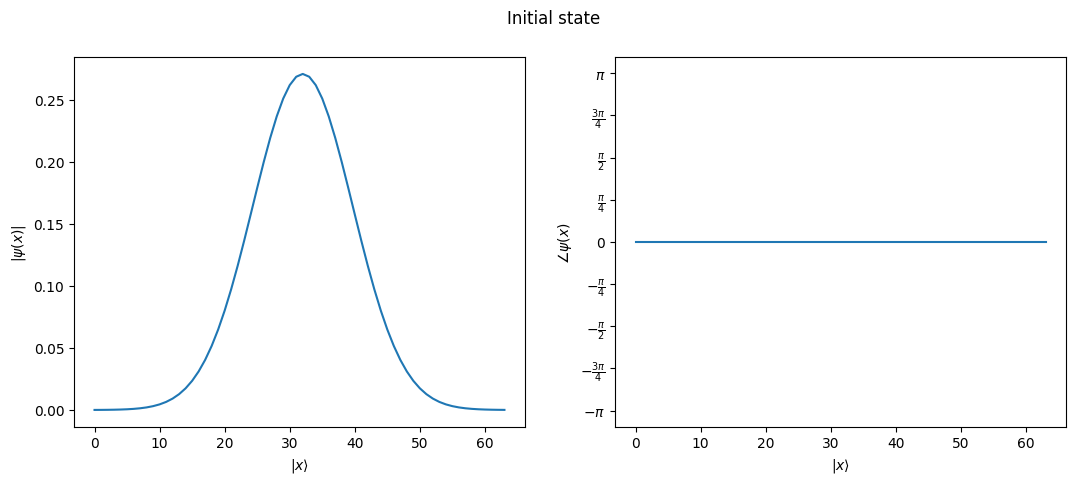

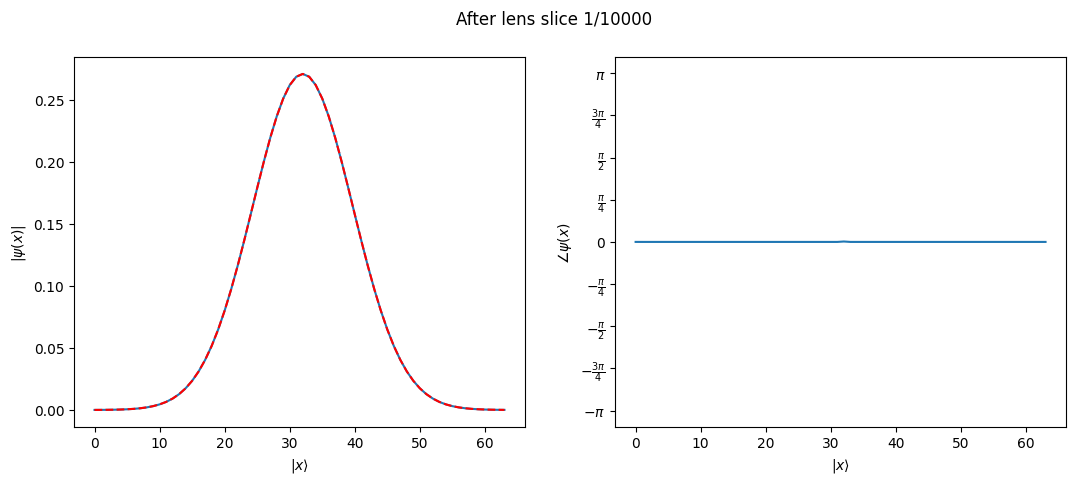

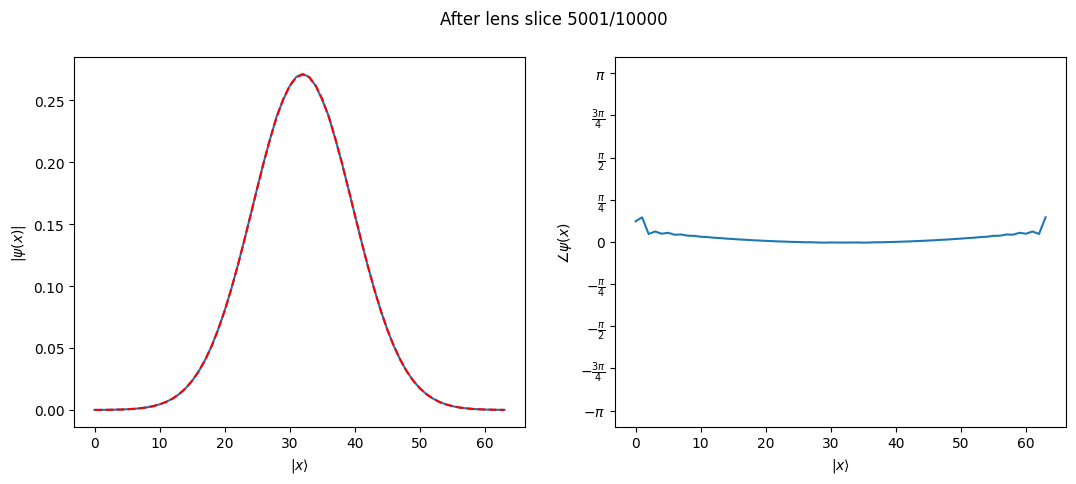

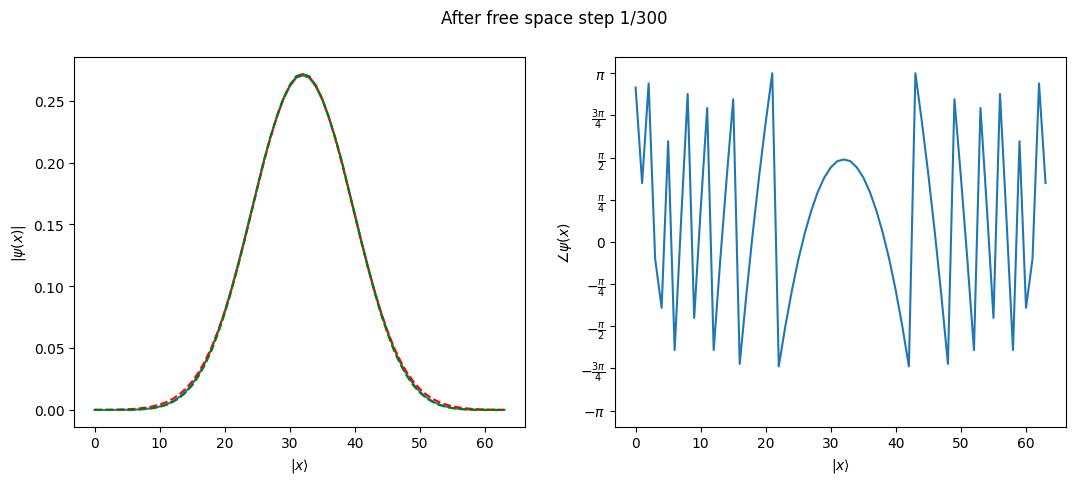

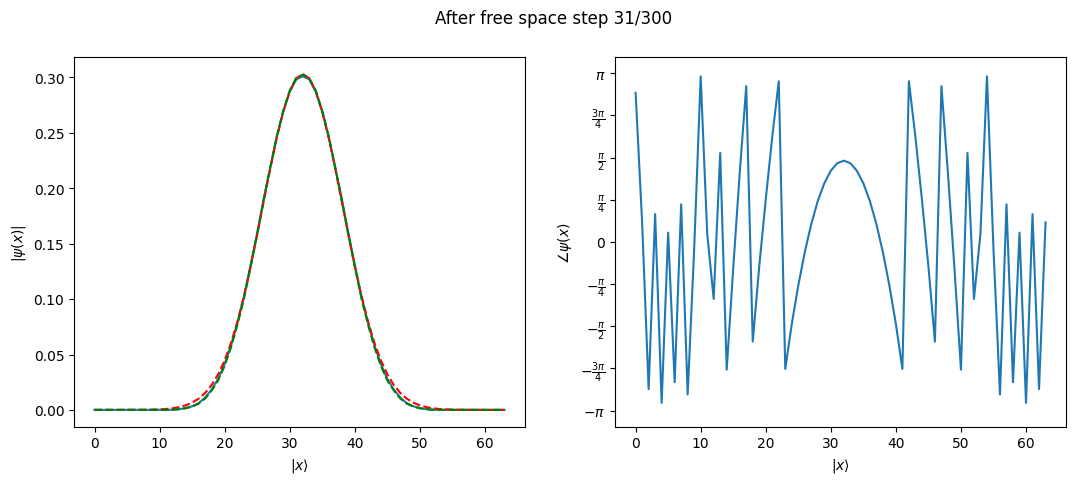

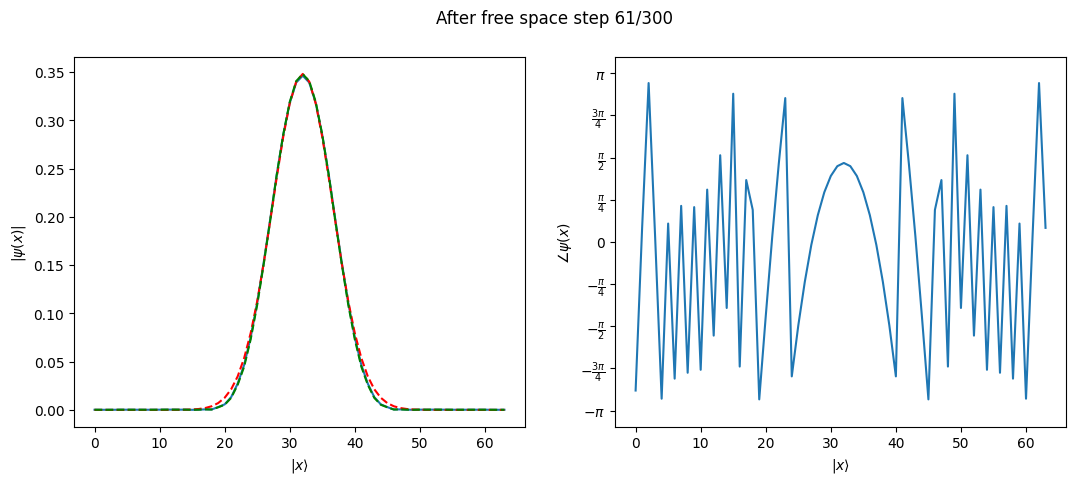

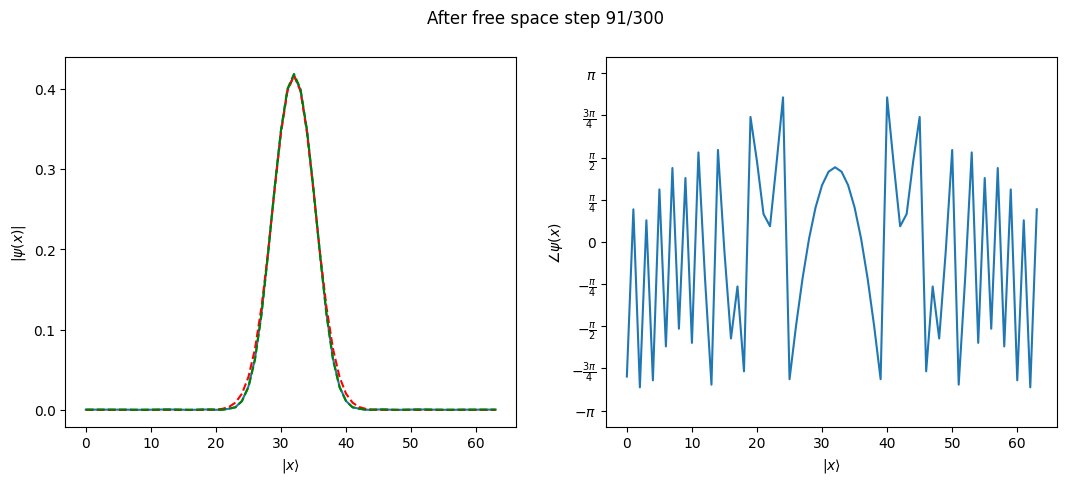

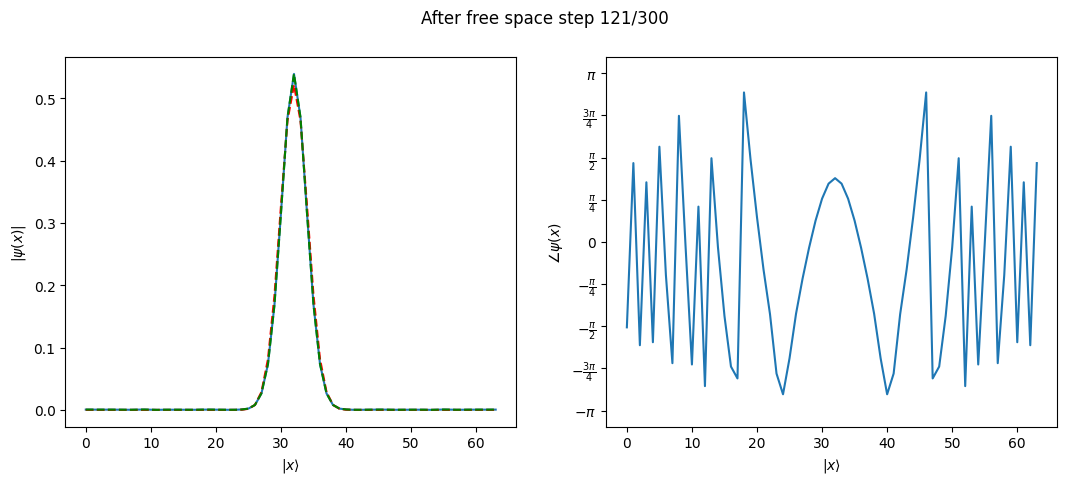

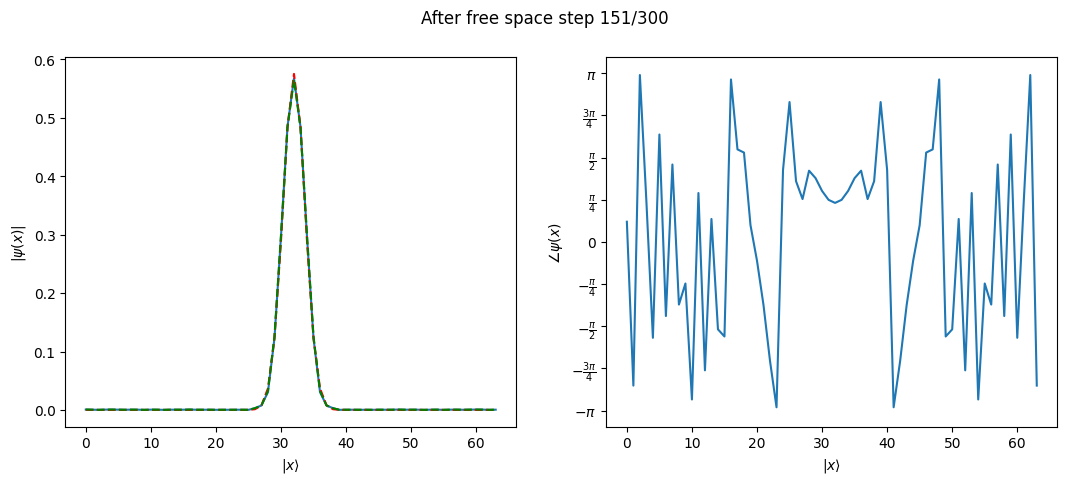

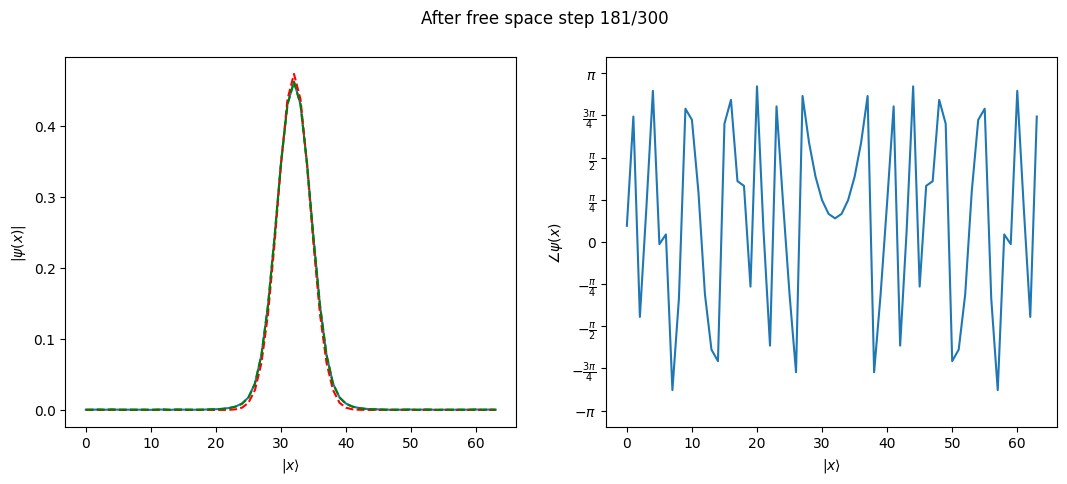

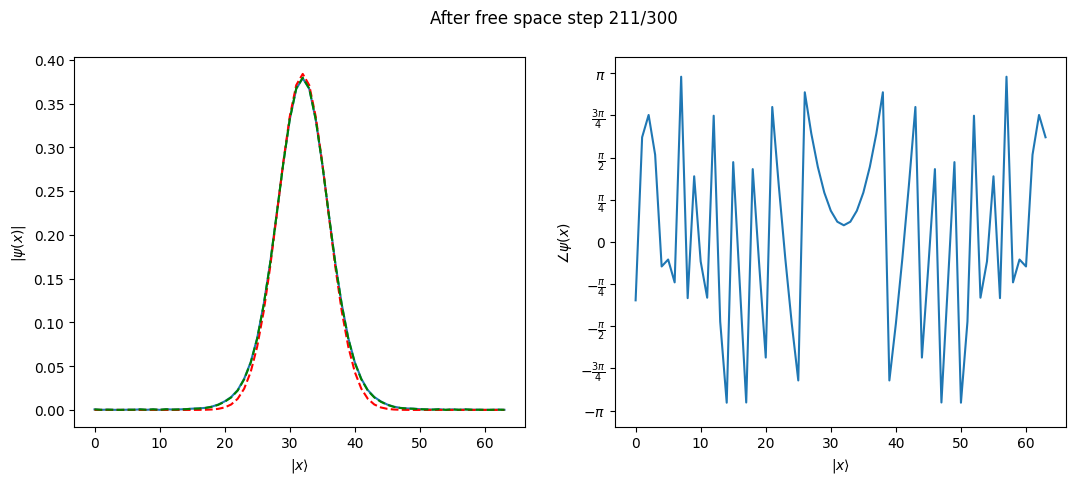

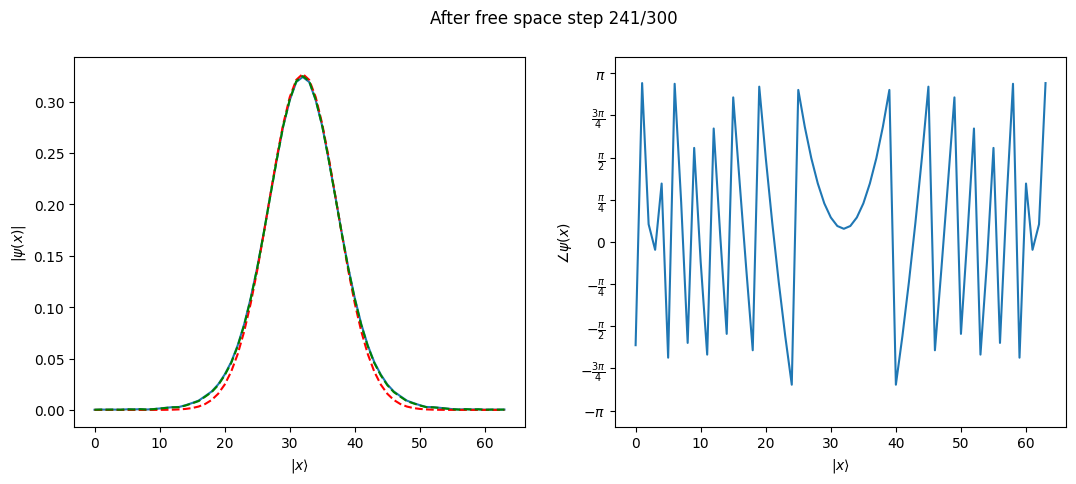

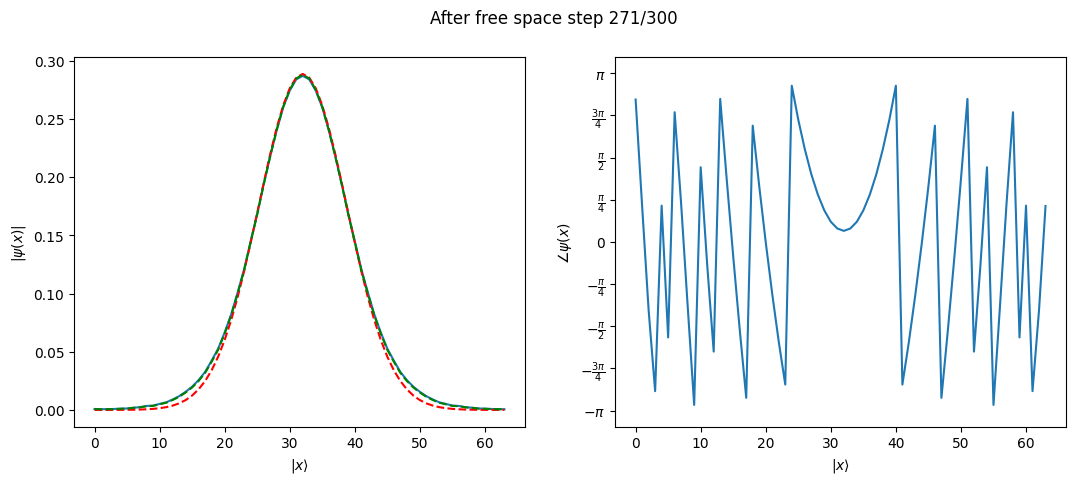

In [32]:
from wave_optics_propagation_enhanced.classical_numerics import (
    classical_numerics_simulation,
    thin_lens_simulation,
)

print("Plotting initial state")
plot_wavefunction(initial_statevector, plot_size_scale=1, normalize=True)
plt.suptitle("Initial state")
plt.show()

NUM_OF_LENS_SLICES_TO_PLOT = 1
NUM_OF_AFTER_LENS_SLICES_TO_PLOT = 10

for i, statevector in enumerate(lens_statevectors):
    if statevector is None:
        continue
    if (
        results.total_lenses_simulated > NUM_OF_LENS_SLICES_TO_PLOT
        and i % (results.total_lenses_simulated // NUM_OF_LENS_SLICES_TO_PLOT) != 0
    ):
        continue

    # print(f"Plotting lens slice {i + 1}/{lens_slices}")

    fig, (ax1, ax2) = plot_wavefunction(statevector, plot_size_scale=1, normalize=True)

    z = params.lens_slice_thickness * (i + 1)

    # because of the principle plane position being on the second surface, the analytical solution in the lens is of a free space propagation
    analytical_result = thin_lens_simulation(
        params,
        propagation_before_lens=z,
        propagation_after_lens=0,
    )
    ax1.plot(np.abs(analytical_result), "r--", label="thin lens analytical")

    plt.suptitle(f"After lens slice {i + 1}/{params.lens_slices}")
    plt.show()

for i, statevector in enumerate(after_lens_statevectors):
    if statevector is None:
        continue
    if i % (params.num_of_steps_after_lens // NUM_OF_AFTER_LENS_SLICES_TO_PLOT) != 0:
        continue

    # print(f"Plotting free space step {i + 1}/{num_of_steps_after_lens}")
    fig, (ax1, ax2) = plot_wavefunction(statevector, plot_size_scale=1, normalize=True)

    after_lens_distance = params.step_size_after_lens * (i + 1)

    # because of the principle plane position being on the second surface, the analytical solution in the lens is of a free space propagation
    analytical_result = thin_lens_simulation(
        params,
        propagation_before_lens=params.lens_thickness,
        propagation_after_lens=after_lens_distance,
    )

    classical_numerics_result = classical_numerics_simulation(
        params, propagation_after_lens=after_lens_distance
    )

    ax1.plot(np.abs(analytical_result), "r--", label="thin lens analytical")

    ax1.plot(np.abs(classical_numerics_result), "g--", label="classical numerics")

    plt.suptitle(f"After free space step {i + 1}/{params.num_of_steps_after_lens}")
    plt.show()

## Beam waist plots


In [33]:
# map each statevector after lens to its corresponding beam waist

# TODO: verify beam waist calculation
def map_statevector_to_beam_waist(statevector: np.ndarray) -> float:
    intensity = np.abs(statevector) ** 2
    total_intensity = np.sum(intensity)
    x_mean = np.sum(params.x_axis.axis_values * intensity) / total_intensity
    x2_mean = np.sum((params.x_axis.axis_values**2) * intensity) / total_intensity
    variance = x2_mean - x_mean**2
    beam_waist = np.sqrt(variance) * 2  # beam waist approximation
    return beam_waist


classical_numerics_beam_waists = []
analytical_beam_waists = []

for i, statevector in enumerate(after_lens_statevectors):
    # if statevector is None:
    #     continue
    # if i % (params.num_of_steps_after_lens // NUM_OF_AFTER_LENS_SLICES_TO_PLOT) != 0:
    #     continue

    after_lens_distance = params.step_size_after_lens * (i + 1)

    # because of the principle plane position being on the second surface, the analytical solution in the lens is of a free space propagation
    analytical_result = thin_lens_simulation(
        params,
        propagation_before_lens=params.lens_thickness,
        propagation_after_lens=after_lens_distance,
    )

    classical_numerics_result = classical_numerics_simulation(
        params, propagation_after_lens=after_lens_distance
    )

    analytical_beam_waists.append(map_statevector_to_beam_waist(analytical_result))

    classical_numerics_beam_waists.append(
        map_statevector_to_beam_waist(classical_numerics_result)
    )

beam_waists = [
    map_statevector_to_beam_waist(statevector)
    for statevector in after_lens_statevectors
    if statevector is not None
]

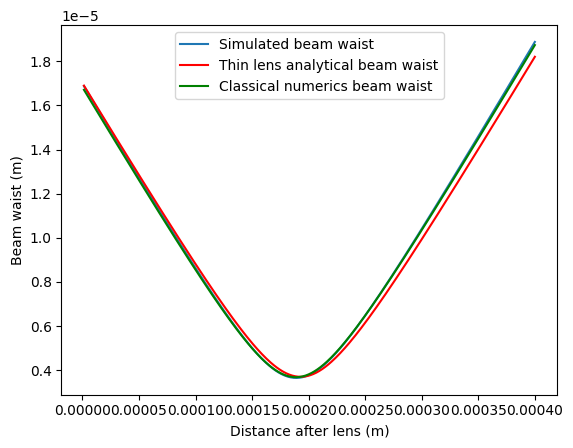

In [34]:
from wave_optics_propagation.BeamProp_Script import prop, q1_inv_func

distance_axis = (np.arange(len(beam_waists)) + 1) * params.step_size_after_lens

# plot beam waists
plt.plot(
    distance_axis,
    beam_waists,
    "-",
    label="Simulated beam waist",
)

plt.plot(
    distance_axis,
    analytical_beam_waists,
    "r-",
    label="Thin lens analytical beam waist",
)

plt.plot(
    distance_axis,
    classical_numerics_beam_waists,
    "g-",
    label="Classical numerics beam waist",
)

ideal_focal_point = params.focal_length - params.lens_thickness
_, beam_waist_after_lens = q1_inv_func(
    0,
    params.gaussian_beam_waist,
    params.reduced_wavelength,
    prop(params.lens_thickness),
)

# plt.axvline(
#     x=ideal_focal_point,
#     color="black",
#     linestyle="--",
#     label="Ideal focal point",
# )
# plt.axhline(
#     y=beam_waist_after_lens,
#     color="gray",
#     linestyle="--",
#     label="Initial beam waist",
# )

plt.xlabel("Distance after lens (m)")
plt.ylabel("Beam waist (m)")
plt.legend()
plt.show()

TypeError: Image data of dtype complex128 cannot be converted to float

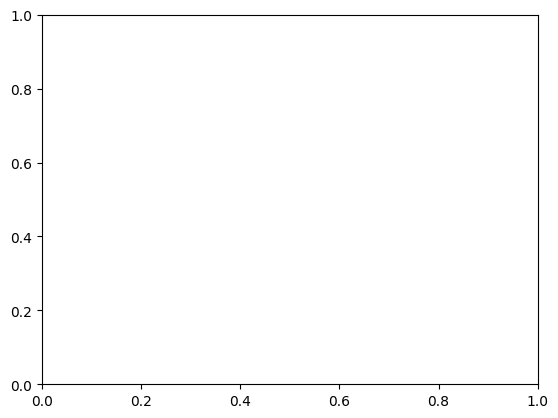

In [ ]:
plt.imshow([np.abs(state) for state in after_lens_statevectors], aspect="auto")
